<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab-03/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab02 - ML - Assignment
BL.SC.U4CSE24070 - Tabrej Ansari

CSE - A

# Mandatory Questions

In [2]:
#Uploading the excel file
from google.colab import files

uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data.xlsx


In [4]:
#Looking at the columns
import pandas as pd

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

# Display the first 5 rows
print(df.head())

# Display all column names
print("\nColumn Names:\n")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6   
4           19-01-2014       94       173  ...                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  \
0             0             0            

In [5]:

# A1
# Study the dataset columns and their datatypem

def get_dataset_information(dataframe):
    """
    Returns column names, data types and number of unique values.
    """
    information = pd.DataFrame({
        "Feature": dataframe.columns,
        "Data Type": dataframe.dtypes.astype(str),
        "Unique Values": dataframe.nunique().values
    })

    return information

# Main Program
dataset_info = get_dataset_information(df)

print("Dataset Information:\n")
print(dataset_info)


Dataset Information:

                                 Feature Data Type  Unique Values
ID                                    ID     int64           2240
Year_Birth                    Year_Birth     int64             59
Education                      Education    object              5
Marital_Status            Marital_Status    object              8
Income                            Income   float64           1974
Kidhome                          Kidhome     int64              3
Teenhome                        Teenhome     int64              3
Dt_Customer                  Dt_Customer    object            663
Recency                          Recency     int64            100
MntWines                        MntWines     int64            776
MntFruits                      MntFruits     int64            158
MntMeatProducts          MntMeatProducts     int64            558
MntFishProducts          MntFishProducts     int64            182
MntSweetProducts        MntSweetProducts     int64    

In [6]:

# A2
# Write separate functions for Label Encoding and
# One-Hot Encoding

import pandas as pd

# Function for Label Encoding
def label_encode(column):
    """
    Performs Label Encoding on a categorical column.
    Returns:
        encoded_column : Encoded values
        mapping : Dictionary used for encoding
    """

    unique_values = sorted(column.dropna().unique())

    mapping = {}

    for index, value in enumerate(unique_values):
        mapping[value] = index

    encoded_column = column.map(mapping)

    return encoded_column, mapping


# Function for One-Hot Encoding
def one_hot_encode(dataframe, column_name):
    """
    Performs One-Hot Encoding on the given column.
    Returns:
        Encoded DataFrame
    """

    encoded_dataframe = dataframe.copy()

    unique_values = dataframe[column_name].dropna().unique()

    for value in unique_values:

        new_column = column_name + "_" + str(value)

        encoded_dataframe[new_column] = (
            dataframe[column_name] == value
        ).astype(int)

    encoded_dataframe.drop(columns=[column_name], inplace=True)

    return encoded_dataframe


# Main Program
# Label Encoding on Education
education_encoded, education_mapping = label_encode(df["Education"])

print("Education Label Encoding:")
print(education_mapping)
print()

# Label Encoding on Marital Status
marital_encoded, marital_mapping = label_encode(df["Marital_Status"])

print("Marital Status Label Encoding:")
print(marital_mapping)
print()

# One-Hot Encoding on Education
education_onehot = one_hot_encode(df, "Education")

print("Columns after One-Hot Encoding of Education:")
print(education_onehot.columns.tolist())
print()

# One-Hot Encoding on Marital Status
marital_onehot = one_hot_encode(df, "Marital_Status")

print("Columns after One-Hot Encoding of Marital Status:")
print(marital_onehot.columns.tolist())

Education Label Encoding:
{'2n Cycle': 0, 'Basic': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}

Marital Status Label Encoding:
{'Absurd': 0, 'Alone': 1, 'Divorced': 2, 'Married': 3, 'Single': 4, 'Together': 5, 'Widow': 6, 'YOLO': 7}

Columns after One-Hot Encoding of Education:
['ID', 'Year_Birth', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Education_Graduation', 'Education_PhD', 'Education_Master', 'Education_Basic', 'Education_2n Cycle']

Columns after One-Hot Encoding of Marital Status:
['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProduct

In [7]:

# A3
# Convert categorical features using Label Encoding and
# One-Hot Encoding. Compare feature dimensionality.

# Create copies of the original dataset
label_encoded_df = df.copy()
onehot_encoded_df = df.copy()

# Apply Label Encoding

# Education
education_encoded, education_mapping = label_encode(
    label_encoded_df["Education"]
)
label_encoded_df["Education"] = education_encoded

# Marital Status
marital_encoded, marital_mapping = label_encode(
    label_encoded_df["Marital_Status"]
)
label_encoded_df["Marital_Status"] = marital_encoded


# Apply One-Hot Encoding
onehot_encoded_df = one_hot_encode(
    onehot_encoded_df,
    "Education"
)

onehot_encoded_df = one_hot_encode(
    onehot_encoded_df,
    "Marital_Status"
)


# Main Program
print("Original Dataset Shape")
print(df.shape)

print("\nLabel Encoded Dataset Shape")
print(label_encoded_df.shape)

print("\nOne-Hot Encoded Dataset Shape")
print(onehot_encoded_df.shape)

print("\n")

print("Original Number of Features :", df.shape[1])
print("After Label Encoding        :", label_encoded_df.shape[1])
print("After One-Hot Encoding      :", onehot_encoded_df.shape[1])

print("\nEducation Mapping")
print(education_mapping)

print("\nMarital Status Mapping")
print(marital_mapping)

print("\nFirst 5 Rows of Label Encoded Dataset")
print(label_encoded_df.head())

print("\nFirst 5 Rows of One-Hot Encoded Dataset")
print(onehot_encoded_df.head())

Original Dataset Shape
(2240, 29)

Label Encoded Dataset Shape
(2240, 29)

One-Hot Encoded Dataset Shape
(2240, 40)


Original Number of Features : 29
After Label Encoding        : 29
After One-Hot Encoding      : 40

Education Mapping
{'2n Cycle': 0, 'Basic': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}

Marital Status Mapping
{'Absurd': 0, 'Alone': 1, 'Divorced': 2, 'Married': 3, 'Single': 4, 'Together': 5, 'Widow': 6, 'YOLO': 7}

First 5 Rows of Label Encoded Dataset
     ID  Year_Birth  Education  Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957          2               4  58138.0        0         0   
1  2174        1954          2               4  46344.0        1         1   
2  4141        1965          2               5  71613.0        0         0   
3  6182        1984          2               5  26646.0        1         0   
4  5324        1981          4               3  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisi

In [8]:

# A4
# Generalized Minkowski Distance Function
import numpy as np

# Function to calculate Minkowski Distance
def minkowski_distance(vector1, vector2, p):
    """
    Calculates the generalized Minkowski distance between
    two vectors.

    Parameters:
        vector1 : First feature vector
        vector2 : Second feature vector
        p       : Order of the distance

    Returns:
        Minkowski distance
    """

    vector1 = np.array(vector1, dtype=float)
    vector2 = np.array(vector2, dtype=float)

    distance = np.sum(np.abs(vector1 - vector2) ** p) ** (1 / p)

    return distance


# Main Program
# Select two feature vectors (first two rows)
feature_columns = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

vector1 = df.loc[0, feature_columns]
vector2 = df.loc[1, feature_columns]

# Manhattan Distance (p = 1)
manhattan_distance = minkowski_distance(vector1, vector2, 1)

# Euclidean Distance (p = 2)
euclidean_distance = minkowski_distance(vector1, vector2, 2)

print("Manhattan Distance (p = 1):")
print(manhattan_distance)

print("\nEuclidean Distance (p = 2):")
print(euclidean_distance)

Manhattan Distance (p = 1):
13427.0

Euclidean Distance (p = 2):
11825.003805496217


Minkowski Distance for different p values

p = 1 : 13427.0
p = 2 : 11825.003805496217
p = 3 : 11794.975787148614
p = 4 : 11794.036213715499
p = 5 : 11794.001454169289
p = 6 : 11794.000061245157
p = 7 : 11794.00000266629
p = 8 : 11794.000000118998
p = 9 : 11794.00000000541
p = 10 : 11794.000000000256


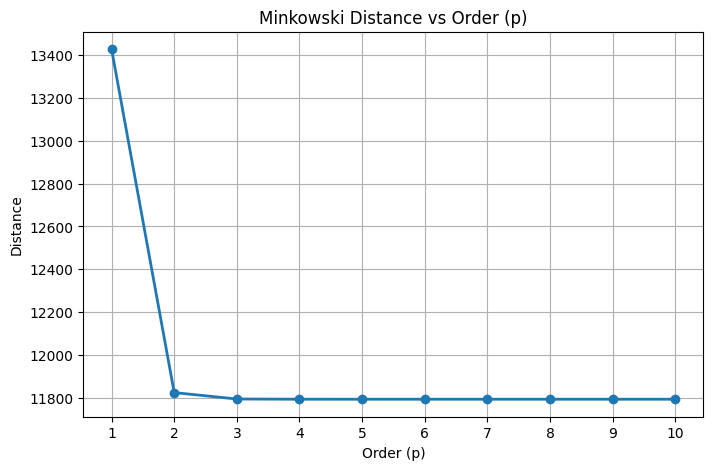

In [9]:

# A5
# Calculate Minkowski Distance for p = 1 to 10
# and plot the graph
import matplotlib.pyplot as plt

# Select two feature vectors
feature_columns = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

vector1 = df.loc[0, feature_columns]
vector2 = df.loc[1, feature_columns]

# Calculate distances for p = 1 to 10
p_values = []
distance_values = []

for p in range(1, 11):

    distance = minkowski_distance(vector1, vector2, p)

    p_values.append(p)
    distance_values.append(distance)

# Display distances
print("Minkowski Distance for different p values\n")

for p, distance in zip(p_values, distance_values):
    print(f"p = {p} : {distance}")

# Plot the graph
plt.figure(figsize=(8,5))

plt.plot(
    p_values,
    distance_values,
    marker="o",
    linewidth=2
)

plt.title("Minkowski Distance vs Order (p)")
plt.xlabel("Order (p)")
plt.ylabel("Distance")

plt.xticks(range(1,11))
plt.grid(True)

plt.show()

In [10]:

# A6
# Compare own Minkowski function with SciPy Minkowski
from scipy.spatial.distance import minkowski


# Select two feature vectors
feature_columns = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

vector1 = df.loc[0, feature_columns].astype(float)
vector2 = df.loc[1, feature_columns].astype(float)


# Compare distance values
print("Comparison of Minkowski Distance\n")

for p in range(1, 11):

    own_distance = minkowski_distance(vector1, vector2, p)

    scipy_distance = minkowski(vector1, vector2, p)

    difference = abs(own_distance - scipy_distance)

    print(f"p = {p}")
    print(f"Own Function   : {own_distance}")
    print(f"SciPy Function : {scipy_distance}")
    print(f"Difference     : {difference}")
    print("-" * 45)

Comparison of Minkowski Distance

p = 1
Own Function   : 13427.0
SciPy Function : 13427.0
Difference     : 0.0
---------------------------------------------
p = 2
Own Function   : 11825.003805496217
SciPy Function : 11825.003805496217
Difference     : 0.0
---------------------------------------------
p = 3
Own Function   : 11794.975787148614
SciPy Function : 11794.975787148614
Difference     : 0.0
---------------------------------------------
p = 4
Own Function   : 11794.036213715499
SciPy Function : 11794.036213715499
Difference     : 0.0
---------------------------------------------
p = 5
Own Function   : 11794.001454169289
SciPy Function : 11794.001454169289
Difference     : 0.0
---------------------------------------------
p = 6
Own Function   : 11794.000061245157
SciPy Function : 11794.000061245157
Difference     : 0.0
---------------------------------------------
p = 7
Own Function   : 11794.00000266629
SciPy Function : 11794.00000266629
Difference     : 0.0
---------------------

In [11]:

# A7
# Dot Product and Euclidean Norm Functions
import numpy as np


# Function to calculate Dot Product
def calculate_dot_product(vector1, vector2):
    """
    Calculates dot product between two vectors.
    """

    result = 0

    for i in range(len(vector1)):
        result += vector1[i] * vector2[i]

    return result


# Function to calculate Euclidean Norm
def calculate_euclidean_norm(vector):
    """
    Calculates Euclidean length (L2 norm) of a vector.
    """

    sum_of_squares = 0

    for value in vector:
        sum_of_squares += value ** 2

    norm = sum_of_squares ** 0.5

    return norm


# Main Program
# Selecting two vectors from dataset
feature_columns = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts"
]


vector_A = df.loc[0, feature_columns].astype(float).values
vector_B = df.loc[1, feature_columns].astype(float).values


# Using user-defined functions
own_dot_product = calculate_dot_product(
    vector_A,
    vector_B
)

own_norm_A = calculate_euclidean_norm(vector_A)

own_norm_B = calculate_euclidean_norm(vector_B)


# Using NumPy functions
numpy_dot_product = np.dot(
    vector_A,
    vector_B
)

numpy_norm_A = np.linalg.norm(
    vector_A
)

numpy_norm_B = np.linalg.norm(
    vector_B
)


# Display Results
print("Dot Product Comparison")
print("---------------------")

print("Own Function:")
print(own_dot_product)

print("\nNumPy dot():")
print(numpy_dot_product)


print("\n\nEuclidean Norm Comparison")
print("------------------------")

print("Vector A")

print("Own Function:")
print(own_norm_A)

print("NumPy Function:")
print(numpy_norm_A)


print("\nVector B")

print("Own Function:")
print(own_norm_B)

print("NumPy Function:")
print(numpy_norm_B)



Dot Product Comparison
---------------------
Own Function:
2694360369.0

NumPy dot():
2694360369.0


Euclidean Norm Comparison
------------------------
Vector A
Own Function:
58144.38130206564
NumPy Function:
58144.38130206564

Vector B
Own Function:
46344.017348520836
NumPy Function:
46344.017348520836


In [12]:

# A8
# User-defined functions for Mean, Variance and
# Standard Deviation calculation
import numpy as np


# Function to calculate Mean
def calculate_mean(data):
    """
    Calculates mean of a set of values.
    """

    total = 0

    for value in data:
        total += value

    mean = total / len(data)

    return mean


# Function to calculate Variance
def calculate_variance(data):
    """
    Calculates variance of a set of values.
    """

    mean_value = calculate_mean(data)

    squared_difference = 0

    for value in data:
        squared_difference += (value - mean_value) ** 2

    variance = squared_difference / len(data)

    return variance


# Function to calculate Standard Deviation
def calculate_standard_deviation(data):
    """
    Calculates standard deviation of a set of values.
    """

    variance = calculate_variance(data)

    standard_deviation = variance ** 0.5

    return standard_deviation


# Function to calculate statistics for dataset matrix
def calculate_dataset_statistics(matrix):
    """
    Calculates mean, variance and standard deviation
    for each feature column of a dataset matrix.
    """

    mean_values = []
    variance_values = []
    standard_deviation_values = []

    for column in matrix.T:

        mean_values.append(
            calculate_mean(column)
        )

        variance_values.append(
            calculate_variance(column)
        )

        standard_deviation_values.append(
            calculate_standard_deviation(column)
        )

    return (
        mean_values,
        variance_values,
        standard_deviation_values
    )


# Main Program
# Select numerical features only
numeric_df = df.select_dtypes(
    include=np.number
)

# Convert dataframe into matrix
dataset_matrix = numeric_df.values


# Calculate statistics using own functions
mean_vector, variance_vector, std_vector = calculate_dataset_statistics(
    dataset_matrix
)


# Display Results
print("Feature Names:")
print(numeric_df.columns.tolist())


print("\nMean Vector:")
print(mean_vector)


print("\nVariance Vector:")
print(variance_vector)


print("\nStandard Deviation Vector:")
print(std_vector)

Feature Names:
['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Mean Vector:
[np.float64(5592.159821428571), np.float64(1968.8058035714287), np.float64(nan), np.float64(0.44419642857142855), np.float64(0.50625), np.float64(49.109375), np.float64(303.9357142857143), np.float64(26.302232142857143), np.float64(166.95), np.float64(37.52544642857143), np.float64(27.06294642857143), np.float64(44.021875), np.float64(2.325), np.float64(4.084821428571429), np.float64(2.6620535714285714), np.float64(5.790178571428571), np.float64(5.316517857142857), np.float64(0.07276785714285715), np.float64(0.07455357142857143), np.float64(0.07276785714285715),

In [13]:

# A9
# Compare user-defined mean and standard deviation
# with NumPy built-in functions
import numpy as np


# Main Program
# Select numerical features only
numeric_df = df.select_dtypes(
    include=np.number
)

# Convert dataframe into matrix
dataset_matrix = numeric_df.values


# Using NumPy built-in functions
numpy_mean_vector = np.mean(
    dataset_matrix,
    axis=0
)

numpy_std_vector = np.std(
    dataset_matrix,
    axis=0
)


# Comparison
print("Feature Names:")
print(numeric_df.columns.tolist())


print("\nComparison of Mean Values")
print("-------------------------")

print("Mean from User Defined Function (A8):")
print(mean_vector)

print("\nMean from NumPy mean():")
print(numpy_mean_vector)


print("\n\nComparison of Standard Deviation Values")
print("--------------------------------------")

print("Standard Deviation from User Defined Function (A8):")
print(std_vector)

print("\nStandard Deviation from NumPy std():")
print(numpy_std_vector)


# Difference Calculation
mean_difference = np.abs(
    np.array(mean_vector) - numpy_mean_vector
)

std_difference = np.abs(
    np.array(std_vector) - numpy_std_vector
)


print("\n\nDifference Between Mean Values:")
print(mean_difference)


print("\nDifference Between Standard Deviation Values:")
print(std_difference)

Feature Names:
['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Comparison of Mean Values
-------------------------
Mean from User Defined Function (A8):
[np.float64(5592.159821428571), np.float64(1968.8058035714287), np.float64(nan), np.float64(0.44419642857142855), np.float64(0.50625), np.float64(49.109375), np.float64(303.9357142857143), np.float64(26.302232142857143), np.float64(166.95), np.float64(37.52544642857143), np.float64(27.06294642857143), np.float64(44.021875), np.float64(2.325), np.float64(4.084821428571429), np.float64(2.6620535714285714), np.float64(5.790178571428571), np.float64(5.316517857142857), np.float64(0.07276785

Feature Selected : Income

Histogram Bucket Counts:
[1654  554    7    0    0    0    0    0    0    1]

Histogram Bin Ranges:
[  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]

Mean of Income:
52247.25135379061

Variance of Income:
633397830.1872728


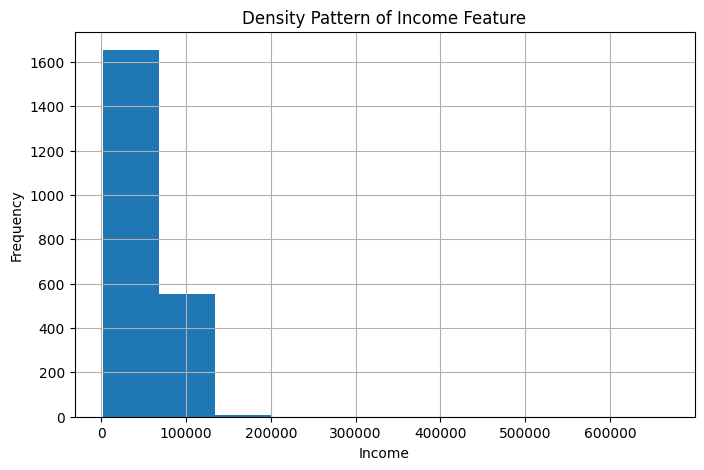

In [14]:

# A10
# Histogram, Mean and Variance calculation for a feature
import numpy as np
import matplotlib.pyplot as plt


# Function to calculate mean
def calculate_feature_mean(data):
    """
    Calculates mean of given data.
    """

    total = 0

    for value in data:
        total += value

    return total / len(data)



# Function to calculate variance
def calculate_feature_variance(data):
    """
    Calculates variance of given data.
    """

    mean_value = calculate_feature_mean(data)

    total = 0

    for value in data:
        total += (value - mean_value) ** 2

    return total / len(data)



# Main Program
# Select a feature
feature_data = df["Income"].dropna().values


# Generate histogram data
hist_values, bins = np.histogram(
    feature_data,
    bins=10
)



# Calculate mean and variance
feature_mean = calculate_feature_mean(
    feature_data
)

feature_variance = calculate_feature_variance(
    feature_data
)


# Display Results
print("Feature Selected : Income")

print("\nHistogram Bucket Counts:")
print(hist_values)

print("\nHistogram Bin Ranges:")
print(bins)

print("\nMean of Income:")
print(feature_mean)

print("\nVariance of Income:")
print(feature_variance)



# Plot Histogram
plt.figure(figsize=(8,5))

plt.hist(
    feature_data,
    bins=10
)

plt.title("Density Pattern of Income Feature")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [15]:

# A11
# Implementation of K-Means Algorithm from Scratch
import numpy as np


# Function to calculate distance
# (Reuse Minkowski distance from A4)
def minkowski_distance(vector1, vector2, p=2):
    """
    Calculates Minkowski distance.
    p = 1 -> Manhattan Distance
    p = 2 -> Euclidean Distance
    """

    distance = np.sum(
        np.abs(vector1 - vector2) ** p
    ) ** (1 / p)

    return distance



# Function to initialize centroids
def initialize_centroids(data, k):
    """
    Selects first k points as initial centroids.
    """

    centroids = data[:k]

    return centroids.copy()



# Function to assign clusters
def assign_clusters(data, centroids):
    """
    Assigns every data point to the nearest centroid.
    """

    clusters = []

    for point in data:

        distances = []

        for centroid in centroids:

            distance = minkowski_distance(
                point,
                centroid,
                p=2
            )

            distances.append(distance)

        nearest_cluster = np.argmin(distances)

        clusters.append(nearest_cluster)

    return np.array(clusters)



# Function to calculate new centroids
def calculate_new_centroids(data, clusters, k):
    """
    Recomputes centroid of each cluster.
    """

    new_centroids = []

    for cluster_number in range(k):

        cluster_points = data[
            clusters == cluster_number
        ]

        centroid = np.mean(
            cluster_points,
            axis=0
        )

        new_centroids.append(centroid)

    return np.array(new_centroids)



# Function to implement K-Means
def k_means(data, k, max_iterations=100):
    """
    Implements basic K-means algorithm.

    Steps:
    1. Select initial centroids
    2. Assign points to closest centroid
    3. Recalculate centroids
    4. Repeat until centroids stop changing
    """

    centroids = initialize_centroids(
        data,
        k
    )


    for iteration in range(max_iterations):

        clusters = assign_clusters(
            data,
            centroids
        )


        new_centroids = calculate_new_centroids(
            data,
            clusters,
            k
        )


        # Stop if centroids do not change
        if np.all(
            centroids == new_centroids
        ):
            break


        centroids = new_centroids


    return clusters, centroids



# Main Program
# Select numerical features
numeric_data = df[
    [
        "Income",
        "MntWines",
        "MntMeatProducts",
        "MntFishProducts"
    ]
].dropna()


# Convert dataframe to numpy matrix
data_matrix = numeric_data.values


# Apply K-means
k = 3

clusters, final_centroids = k_means(
    data_matrix,
    k
)


# Display Results
print("Cluster Assignment:")
print(clusters)


print("\nFinal Centroids:")
print(final_centroids)

Cluster Assignment:
[0 0 2 ... 0 2 0]

Final Centroids:
[[5.56852568e+04 3.47049383e+02 1.24369136e+02 3.16456790e+01]
 [2.98794719e+04 3.90107527e+01 2.79820789e+01 9.52090800e+00]
 [8.02561213e+04 6.36768014e+02 4.32166960e+02 8.75272408e+01]]
